In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/hcvdat0.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (615, 14)


,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [2]:
df.info()
df.describe()
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    object 
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    object 
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 67.4+ KB
['Unnamed: 0', 'Category', 'Age', 'Sex', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']


In [3]:
missing = df.isnull().sum()

print(missing)

Unnamed: 0     0
Category       0
Age            0
Sex            0
ALB            1
ALP           18
ALT            1
AST            0
BIL            0
CHE            0
CHOL          10
CREA           0
GGT            0
PROT           1
dtype: int64


In [4]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [5]:
print(df["Category"].value_counts())

Category
0=Blood Donor             533
3=Cirrhosis                30
1=Hepatitis                24
2=Fibrosis                 21
0s=suspect Blood Donor      7
Name: count, dtype: int64


In [11]:
df[numerical_features].describe().T


,count,mean,std,min,25%,50%,75%,max
Age,615.0,47.408130,10.055105,19.00,39.000,47.00,54.000,77.00
ALB,614.0,41.620195,5.780629,14.90,38.800,41.95,45.200,82.20
ALP,597.0,68.283920,26.028315,11.30,52.500,66.20,80.100,416.60
ALT,614.0,28.450814,25.469689,0.90,16.400,23.00,33.075,325.30
AST,615.0,34.786341,33.090690,10.60,21.600,25.90,32.900,324.00
BIL,615.0,11.396748,19.673150,0.80,5.300,7.30,11.200,254.00
CHE,615.0,8.196634,2.205657,1.42,6.935,8.26,9.590,16.41
CHOL,605.0,5.368099,1.132728,1.43,4.610,5.30,6.060,9.67
CREA,615.0,81.287805,49.756166,8.00,67.000,77.00,88.000,1079.10
GGT,615.0,39.533171,54.661071,4.50,15.700,23.30,40.200,650.90


In [12]:
df.groupby("Category")[numerical_features].median().round(2)

,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
Category,,,,,,,,,,,
0=Blood Donor,47.0,42.2,66.70,23.10,24.8,6.9,8.35,5.40,78.00,21.40,72.20
0s=suspect Blood Donor,55.0,21.6,106.00,49.20,46.7,4.9,5.33,4.30,52.00,83.00,47.80
1=Hepatitis,37.0,43.5,34.60,15.20,47.2,13.0,9.51,5.06,72.25,45.55,73.65
2=Fibrosis,51.0,41.0,39.55,34.00,70.0,13.0,8.59,4.58,71.40,72.20,76.10
3=Cirrhosis,56.0,33.0,80.05,5.65,92.9,34.0,3.42,3.87,68.50,96.35,70.00


In [6]:
print(df["Category"].value_counts(normalize=True) * 100)

Category
0=Blood Donor             86.666667
3=Cirrhosis                4.878049
1=Hepatitis                3.902439
2=Fibrosis                 3.414634
0s=suspect Blood Donor     1.138211
Name: proportion, dtype: float64


In [7]:
print(df["Sex"].value_counts())

Sex
m    377
f    238
Name: count, dtype: int64


In [8]:
feature_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

feature_summary

,Feature,Data Type,Missing Values,Unique Values
Unnamed: 0,Unnamed: 0,int64,0,615
Category,Category,object,0,5
Age,Age,int64,0,49
Sex,Sex,object,0,2
ALB,ALB,float64,1,189
ALP,ALP,float64,18,414
ALT,ALT,float64,1,341
AST,AST,float64,0,297
BIL,BIL,float64,0,188
CHE,CHE,float64,0,407


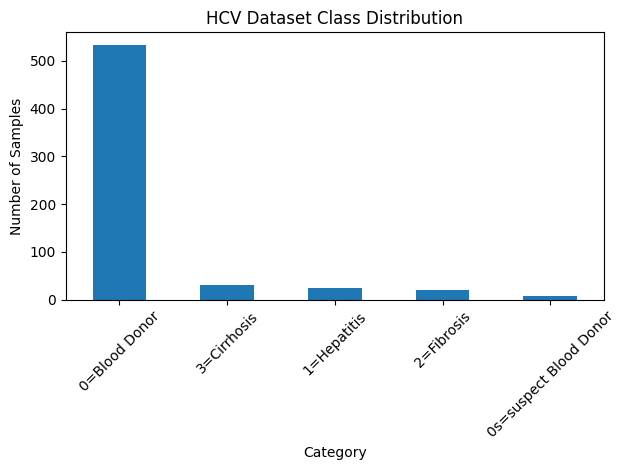

In [9]:
df["Category"].value_counts().plot(kind="bar")

plt.title("HCV Dataset Class Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

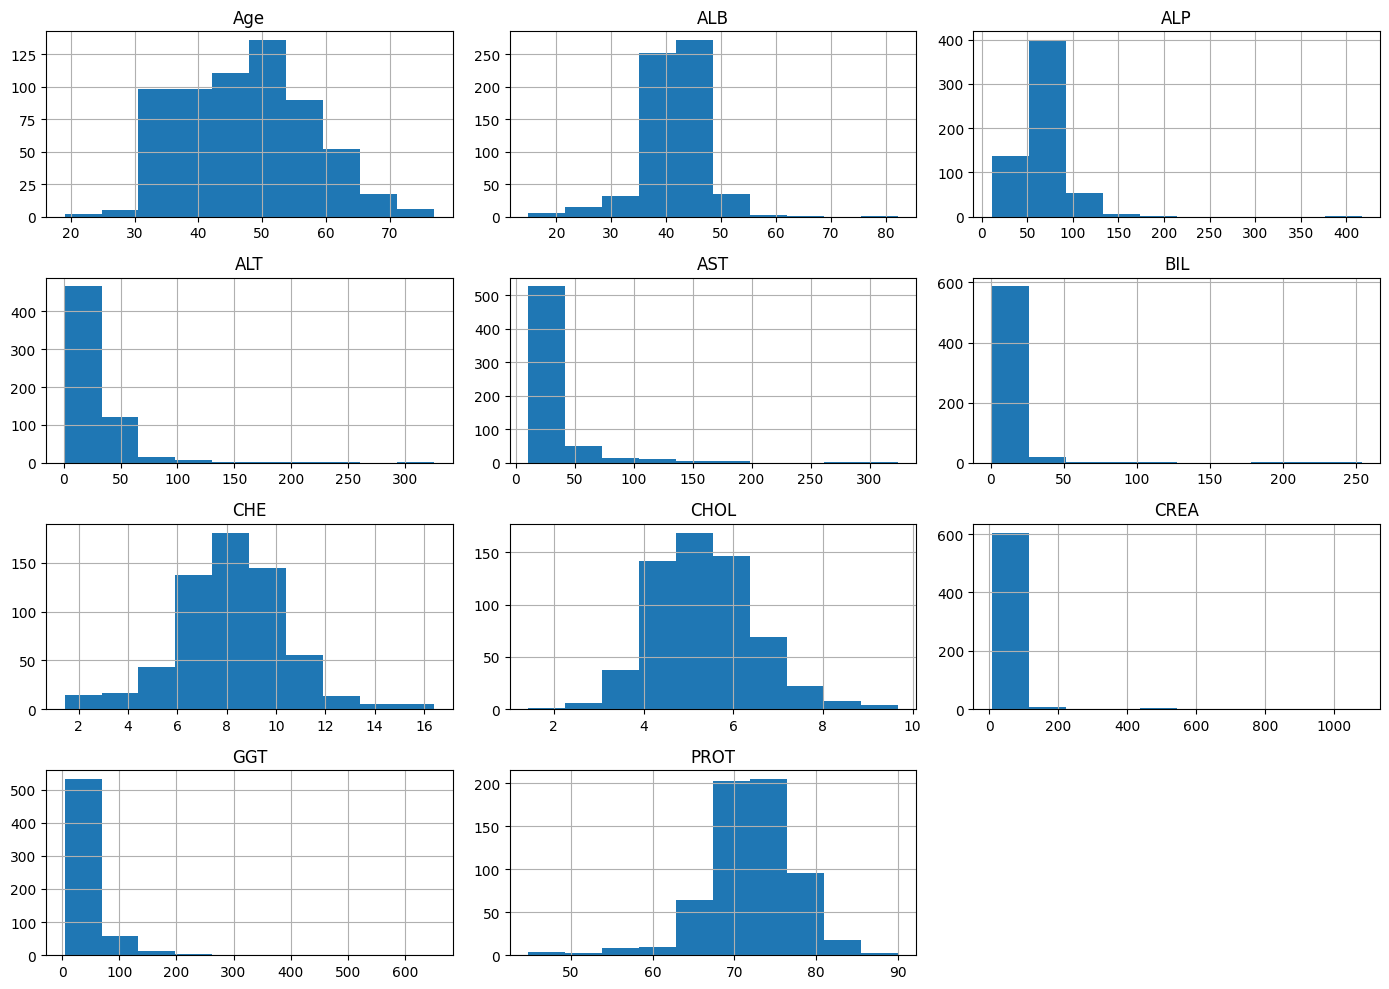

In [10]:
numerical_features = [
    "Age", "ALB", "ALP", "ALT", "AST",
    "BIL", "CHE", "CHOL", "CREA", "GGT", "PROT"
]

df[numerical_features].hist(figsize=(14, 10))

plt.tight_layout()
plt.show()